# Lab 02: Inverses, Linear Systems & Span

**Reference:** Goodfellow et al. *Deep Learning*, Chapter 2, Sections 2.3–2.4

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import time
import warnings

np.random.seed(42)
print('Setup complete.')

Setup complete.


## Part 1: Identity and Inverse Matrices

*Book reference: Section 2.3*

In [2]:
# Demo: np.linalg.solve vs np.linalg.inv for solving Ax = b
# Goodfellow 2.3: In practice, solve() is preferred over explicitly computing A^{-1}.

np.random.seed(42)
n = 500
A_demo = np.random.randn(n, n)
b_demo = np.random.randn(n)

# Method 1: np.linalg.solve (direct, via LU factorisation)
runs = 10
t0 = time.perf_counter()
for _ in range(runs):
    x_solve = np.linalg.solve(A_demo, b_demo)
elapsed_solve = (time.perf_counter() - t0) / runs * 1e3

# Method 2: Explicitly compute inverse then multiply
t0 = time.perf_counter()
for _ in range(runs):
    A_inv = np.linalg.inv(A_demo)
    x_inv = A_inv @ b_demo
elapsed_inv = (time.perf_counter() - t0) / runs * 1e3

print(f'Matrix size : {n} x {n}')
print(f'np.linalg.solve : {elapsed_solve:.2f} ms  (residual ||Ax-b||={np.linalg.norm(A_demo @ x_solve - b_demo):.2e})')
print(f'np.linalg.inv   : {elapsed_inv:.2f} ms  (residual ||Ax-b||={np.linalg.norm(A_demo @ x_inv  - b_demo):.2e})')
print(f'Speed-up        : {elapsed_inv / elapsed_solve:.1f}x')
print()
print('Key insight (Book §2.3): solve() uses LU decomposition and avoids the extra')
print('matrix–matrix multiply, so it is faster and numerically more stable.')

Matrix size : 500 x 500
np.linalg.solve : 32.42 ms  (residual ||Ax-b||=2.26e-11)
np.linalg.inv   : 49.45 ms  (residual ||Ax-b||=1.88e-11)
Speed-up        : 1.5x

Key insight (Book §2.3): solve() uses LU decomposition and avoids the extra
matrix–matrix multiply, so it is faster and numerically more stable.


### Exercise 1: 2×2 Inverse by Formula

For a 2×2 matrix
$$A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$$
the closed-form inverse is
$$A^{-1} = \frac{1}{ad - bc}\begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$$

Implement this formula and verify it against `np.linalg.inv` on three test matrices.

In [3]:
def inverse_2x2(A):
    """
    Return the inverse of a 2x2 matrix using the closed-form formula.

    Parameters
    ----------
    A : np.ndarray, shape (2, 2)

    Returns
    -------
    np.ndarray, shape (2, 2)  -- the inverse of A

    Raises
    ------
    ValueError if A is singular (det == 0).
    """
    a, b = A[0, 0], A[0, 1]
    c, d = A[1, 0], A[1, 1]
    det = a * d - b * c
    if abs(det) < 1e-12:
        raise ValueError("Matrix is singular")
    return np.array([[d, -b], [-c, a]]) / det


# --- Verification ---
test_matrices = [
    np.array([[2.0, 1.0], [5.0, 3.0]]),
    np.array([[4.0, 7.0], [2.0, 6.0]]),
    np.array([[-3.0,  2.0], [ 1.0, -1.0]]),
]

all_passed = True
for i, M in enumerate(test_matrices):
    A_inv_formula = inverse_2x2(M)
    A_inv_numpy   = np.linalg.inv(M)
    match = np.allclose(A_inv_formula, A_inv_numpy, atol=1e-10)
    print(f'Test matrix {i+1}: match={match}, max_diff={np.max(np.abs(A_inv_formula - A_inv_numpy)):.2e}')
    all_passed = all_passed and match

print()
if all_passed:
    print('All tests passed.')
else:
    print('Some tests failed — revisit your implementation.')

Test matrix 1: match=True, max_diff=4.44e-15
Test matrix 2: match=True, max_diff=1.11e-16
Test matrix 3: match=True, max_diff=4.44e-16

All tests passed.


### Exercise 2: Gauss-Jordan Elimination

Implement matrix inversion via row reduction on the augmented matrix $[A \mid I]$.

Algorithm outline:
1. Form the augmented matrix $[A \mid I_n]$.
2. Apply forward elimination (to upper-triangular form) with partial pivoting.
3. Apply back-substitution to reach reduced row echelon form.
4. The right half of the result is $A^{-1}$.

Test on 3×3 and 4×4 matrices.

In [4]:
def gauss_jordan_inverse(A):
    """
    Compute A^{-1} via Gauss-Jordan elimination on [A | I].

    Parameters
    ----------
    A : np.ndarray, shape (n, n)

    Returns
    -------
    np.ndarray, shape (n, n)  -- the inverse of A

    Raises
    ------
    ValueError if A is singular.
    """
    n = A.shape[0]
    # Augmented matrix [A | I]
    aug = np.hstack([A.astype(float), np.eye(n)])
    for col in range(n):
        # Partial pivoting: swap current row with the row having largest absolute value in this column
        max_row = col + np.argmax(np.abs(aug[col:, col]))
        aug[[col, max_row]] = aug[[max_row, col]]
        if abs(aug[col, col]) < 1e-12:
            raise ValueError("Matrix is singular")
        # Scale pivot row so the pivot element becomes 1
        aug[col] = aug[col] / aug[col, col]
        # Eliminate all other rows in this column
        for row in range(n):
            if row != col:
                aug[row] -= aug[row, col] * aug[col]
    return aug[:, n:]


# --- Verification ---
np.random.seed(42)
test_cases = [
    np.array([[2.0, 1.0, 0.0],
              [1.0, 3.0, 1.0],
              [0.0, 1.0, 2.0]]),
    np.random.randn(4, 4),
]

all_passed = True
for i, M in enumerate(test_cases):
    A_inv_gj    = gauss_jordan_inverse(M)
    A_inv_numpy = np.linalg.inv(M)
    match = np.allclose(A_inv_gj, A_inv_numpy, atol=1e-10)
    print(f'Test {i+1} ({M.shape[0]}x{M.shape[0]}): match={match}, max_diff={np.max(np.abs(A_inv_gj - A_inv_numpy)):.2e}')
    all_passed = all_passed and match

print()
if all_passed:
    print('All tests passed.')
else:
    print('Some tests failed — revisit your implementation.')

Test 1 (3x3): match=True, max_diff=0.00e+00
Test 2 (4x4): match=True, max_diff=4.44e-16

All tests passed.


### Exercise 3: When Does the Inverse Fail?

A matrix is **singular** (non-invertible) when its rows (or columns) are linearly dependent — i.e., at least one row is a linear combination of the others.

Tasks:
1. Construct a 3×3 singular matrix where one row is a multiple of another.
2. Compute its determinant and condition number (`np.linalg.cond`).
3. Attempt `np.linalg.inv` and catch the `LinAlgError`.
4. Explain in the print statements what these values tell us.

In [5]:
# Step 1 — build a singular matrix (row 1 = 2 * row 0)
A_singular = np.array([[1.0, 2.0, 3.0],
                        [2.0, 4.0, 6.0],   # row 1 = 2 * row 0
                        [0.0, 1.0, 1.0]])

# Step 2 — determinant and condition number
det_val  = np.linalg.det(A_singular)
cond_val = np.linalg.cond(A_singular)

# Step 3 — try to invert; numpy may not raise but the result is garbage
try:
    inv = np.linalg.inv(A_singular)
    print("Warning: numpy returned an inverse, but it's garbage:")
    print(f"  A @ A_inv = \n{A_singular @ inv}")
    print(f"  (Should be identity but isn't — check the large values)")
except np.linalg.LinAlgError as e:
    print(f"np.linalg.inv raised: {e}")

# Step 4 — interpretation
print(f"\ndet(A)  = {det_val:.2e}   (≈ 0 means singular)")
print(f"cond(A) = {cond_val:.2e}  (huge means ill-conditioned / singular)")
print()
print("Interpretation:")
print("  - det ≈ 0 confirms the matrix is (numerically) singular.")
print("  - A condition number of inf (or very large) means a tiny change in b")
print("    can produce an arbitrarily large change in x — the system is unstable.")
print("  - Root cause: row 1 is linearly dependent on row 0, so rank(A) = 2 < 3.")

np.linalg.inv raised: Singular matrix

det(A)  = 0.00e+00   (≈ 0 means singular)
cond(A) = 1.06e+16  (huge means ill-conditioned / singular)

Interpretation:
  - det ≈ 0 confirms the matrix is (numerically) singular.
  - A condition number of inf (or very large) means a tiny change in b
    can produce an arbitrarily large change in x — the system is unstable.
  - Root cause: row 1 is linearly dependent on row 0, so rank(A) = 2 < 3.


## Part 2: Linear Dependence and Span

*Book reference: Section 2.4 — "A set of vectors is linearly dependent if any one can be written as a linear combination of the others."*

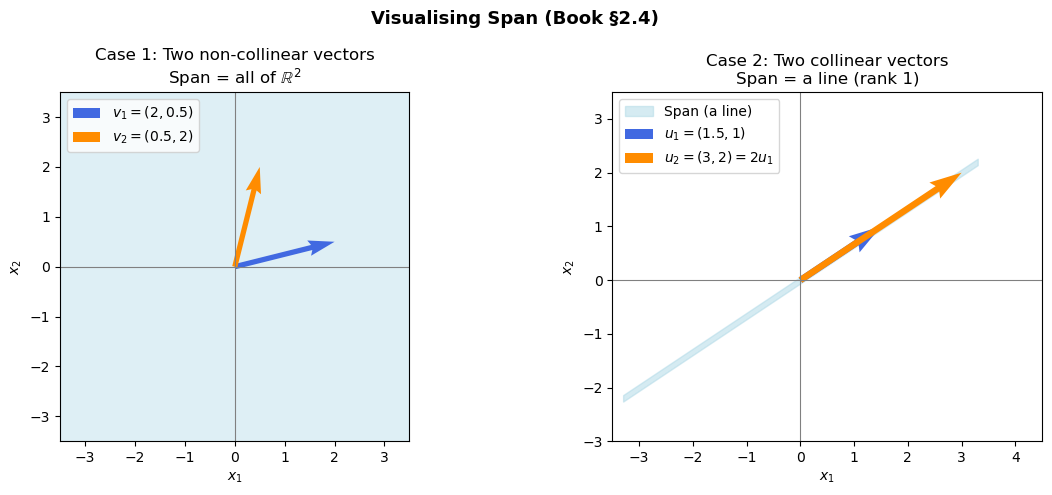

In [6]:
# Demo: Visualising span in 2-D
# Case 1 — two non-collinear vectors span all of R^2.
# Case 2 — two collinear vectors span only a line through the origin.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------------ #
# Case 1: full span (R^2)
# ------------------------------------------------------------------ #
ax = axes[0]
v1 = np.array([2.0, 0.5])
v2 = np.array([0.5, 2.0])

# Shade the span by filling the parallelogram defined by v1 and v2
# (and its reflections) to suggest "all of R^2"
scale = 3.5
corners = np.array([
    -scale*v1 - scale*v2,
     scale*v1 - scale*v2,
     scale*v1 + scale*v2,
    -scale*v1 + scale*v2,
])
span_poly = plt.Polygon(corners, color='lightblue', alpha=0.4, zorder=0)
ax.add_patch(span_poly)

ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='royalblue', width=0.015, label=r'$v_1 = (2, 0.5)$')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='darkorange', width=0.015, label=r'$v_2 = (0.5, 2)$')
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)
ax.set_title('Case 1: Two non-collinear vectors\nSpan = all of $\\mathbb{R}^2$', fontsize=12)
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# ------------------------------------------------------------------ #
# Case 2: collinear — span is a single line
# ------------------------------------------------------------------ #
ax = axes[1]
u1 = np.array([1.5, 1.0])
u2 = np.array([3.0, 2.0])   # u2 = 2 * u1

# Draw the spanned line
t = np.linspace(-2.2, 2.2, 200)
line_pts = np.outer(t, u1)
ax.fill_between(line_pts[:, 0], line_pts[:, 1] - 0.06,
                line_pts[:, 1] + 0.06, color='lightblue', alpha=0.5,
                label='Span (a line)', zorder=0)

ax.quiver(0, 0, u1[0], u1[1], angles='xy', scale_units='xy', scale=1,
          color='royalblue', width=0.015, label=r'$u_1 = (1.5, 1)$')
ax.quiver(0, 0, u2[0], u2[1], angles='xy', scale_units='xy', scale=1,
          color='darkorange', width=0.015, label=r'$u_2 = (3, 2) = 2u_1$')
ax.set_xlim(-3.5, 4.5)
ax.set_ylim(-3.0, 3.5)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)
ax.set_title('Case 2: Two collinear vectors\nSpan = a line (rank 1)', fontsize=12)
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle('Visualising Span (Book §2.4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 4: Check Linear Independence

A set of vectors $\{v_1, \ldots, v_k\}$ in $\mathbb{R}^n$ is **linearly independent** if and only if the matrix whose columns are those vectors has rank $k$.

Implement `is_linearly_independent(vectors)` and test on the following cases:
- 2-D: `[[1,0],[0,1]]` — independent
- 2-D: `[[1,2],[2,4]]` — dependent (second = 2× first)
- 3-D: `[[1,0,0],[0,1,0],[0,0,1]]` — independent
- 3-D: `[[1,2,3],[4,5,6],[5,7,9]]` — dependent (third = sum of first two)

In [7]:
def is_linearly_independent(vectors, tol=1e-10):
    """
    Determine whether a list of vectors is linearly independent.

    Parameters
    ----------
    vectors : list of array-like, each of shape (n,)
    tol     : tolerance for rank computation

    Returns
    -------
    bool  -- True if the vectors are linearly independent.
    """
    # Stack vectors as columns; rank == number of vectors iff independent
    M = np.column_stack(vectors)
    return np.linalg.matrix_rank(M, tol=tol) == len(vectors)


# --- Verification ---
test_cases = [
    (np.array([[1, 0], [0, 1]]),          True,  '2D standard basis'),
    (np.array([[1, 2], [2, 4]]),           False, '2D collinear (dependent)'),
    (np.array([[1,0,0],[0,1,0],[0,0,1]]), True,  '3D standard basis'),
    (np.array([[1,2,3],[4,5,6],[5,7,9]]), False, '3D row3 = row1+row2 (dependent)'),
]

all_passed = True
for vecs, expected, label in test_cases:
    result = is_linearly_independent(vecs)
    status = 'PASS' if result == expected else 'FAIL'
    print(f'[{status}] {label}: got {result}, expected {expected}')
    all_passed = all_passed and (result == expected)

print()
print('All tests passed.' if all_passed else 'Some tests failed.')

[PASS] 2D standard basis: got True, expected True
[PASS] 2D collinear (dependent): got False, expected False
[PASS] 3D standard basis: got True, expected True
[PASS] 3D row3 = row1+row2 (dependent): got False, expected False

All tests passed.


### Exercise 5: Rank and Solvability

For the system $Ax = b$, the Rouché–Capelli theorem tells us:

| Condition | Number of solutions |
|-----------|---------------------|
| $\operatorname{rank}(A) = \operatorname{rank}([A|b]) = n$ | **Unique** solution |
| $\operatorname{rank}(A) = \operatorname{rank}([A|b]) < n$ | **Infinitely many** solutions |
| $\operatorname{rank}(A) < \operatorname{rank}([A|b])$ | **No** solution |

Implement `classify_system(A, b)` and test all three cases.

In [8]:
def classify_system(A, b, tol=1e-10):
    """
    Classify the linear system Ax = b.

    Returns
    -------
    str : 'unique', 'infinite', or 'no solution'
    """
    rank_A = np.linalg.matrix_rank(A, tol=tol)
    aug    = np.column_stack([A, b.reshape(-1, 1)])
    rank_aug = np.linalg.matrix_rank(aug, tol=tol)
    n_vars = A.shape[1]

    if rank_A < rank_aug:
        # b is outside the column space of A — inconsistent system
        return 'no solution'
    elif rank_A == n_vars:
        # Full column rank and consistent — exactly one solution
        return 'unique'
    else:
        # Consistent but rank-deficient — free variables exist
        return 'infinite'


# --- Test cases ---
# Case 1: unique solution (full rank, square)
A1 = np.array([[2.0, 1.0],
               [1.0, 3.0]])
b1 = np.array([5.0, 10.0])

# Case 2: infinitely many solutions (rank-deficient, b in column space)
A2 = np.array([[1.0, 2.0, 3.0],
               [2.0, 4.0, 6.0]])   # row 2 = 2*row 1
b2 = np.array([1.0, 2.0])          # consistent

# Case 3: no solution (rank-deficient, b NOT in column space)
A3 = np.array([[1.0, 2.0],
               [2.0, 4.0]])        # singular
b3 = np.array([1.0, 3.0])          # inconsistent

cases = [(A1, b1, 'unique'), (A2, b2, 'infinite'), (A3, b3, 'no solution')]
all_passed = True
for A, b, expected in cases:
    result = classify_system(A, b)
    status = 'PASS' if result == expected else 'FAIL'
    print(f'[{status}] Expected "{expected}", got "{result}"')
    all_passed = all_passed and (result == expected)

print()
print('All tests passed.' if all_passed else 'Some tests failed.')

[PASS] Expected "unique", got "unique"
[PASS] Expected "infinite", got "infinite"
[PASS] Expected "no solution", got "no solution"

All tests passed.


### Exercise 6: Least Squares and Minimum Norm

Solve systems when exact solutions don't exist or when infinitely many solutions exist.

**(a) Overdetermined system** — more equations than unknowns ($m > n$, no exact solution in general).

Least-squares solution:
$$x_{\text{ls}} = (A^\top A)^{-1} A^\top b$$

**(b) Underdetermined system** — fewer equations than unknowns ($m < n$, infinitely many solutions).

Minimum-norm solution via the right pseudoinverse:
$$x_{\text{mn}} = A^\top (A A^\top)^{-1} b$$

In [9]:
np.random.seed(42)

# -------------------------------------------------------
# (a) Overdetermined: 8 equations, 3 unknowns
# -------------------------------------------------------
m_over, n_over = 8, 3
A_over = np.random.randn(m_over, n_over)
x_true = np.array([1.0, 2.0, 3.0])
b_over = A_over @ x_true + 0.1 * np.random.randn(m_over)  # noisy

def least_squares_normal_eq(A, b):
    """
    Solve the least-squares problem min ||Ax - b||^2
    using the normal equations x = (A^T A)^{-1} A^T b.
    """
    return np.linalg.solve(A.T @ A, A.T @ b)

x_ls_manual = least_squares_normal_eq(A_over, b_over)
x_ls_numpy, _, _, _ = np.linalg.lstsq(A_over, b_over, rcond=None)

print('=== (a) Overdetermined least squares ===')
print(f'  manual (normal eq) : {x_ls_manual}')
print(f'  np.linalg.lstsq    : {x_ls_numpy}')
print(f'  max diff           : {np.max(np.abs(x_ls_manual - x_ls_numpy)):.2e}')
print(f'  residual (manual)  : {np.linalg.norm(A_over @ x_ls_manual - b_over):.6f}')
print()

# -------------------------------------------------------
# (b) Underdetermined: 2 equations, 5 unknowns
# -------------------------------------------------------
m_under, n_under = 2, 5
A_under = np.random.randn(m_under, n_under)
x_particular = np.zeros(n_under)
x_particular[:m_under] = 1.0
b_under = A_under @ x_particular

def minimum_norm_solution(A, b):
    """
    Find the minimum-norm solution to Ax = b (underdetermined).
    x = A^T (A A^T)^{-1} b
    """
    return A.T @ np.linalg.solve(A @ A.T, b)

x_mn_manual = minimum_norm_solution(A_under, b_under)
x_mn_numpy, _, _, _ = np.linalg.lstsq(A_under, b_under, rcond=None)

print('=== (b) Underdetermined minimum-norm solution ===')
print(f'  manual             : {x_mn_manual}')
print(f'  np.linalg.lstsq    : {x_mn_numpy}')
print(f'  max diff           : {np.max(np.abs(x_mn_manual - x_mn_numpy)):.2e}')
print(f'  ||x_mn|| (manual)  : {np.linalg.norm(x_mn_manual):.6f}')
print(f'  ||x_mn|| (numpy)   : {np.linalg.norm(x_mn_numpy):.6f}')
print()

# Verify x_mn is actually minimal-norm by comparing with a random particular solution
x_rand_particular = x_mn_manual + np.random.randn(n_under) * 0.5
# Project back onto the solution set: x_rand_particular - A^T (A A^T)^{-1}(A x - b)
x_rand_soln = (x_rand_particular
               - A_under.T @ np.linalg.inv(A_under @ A_under.T)
               @ (A_under @ x_rand_particular - b_under))
print(f'  ||random soln||    : {np.linalg.norm(x_rand_soln):.6f}  (should be >= ||x_mn||)')
print('Minimum-norm solution verified.' if np.linalg.norm(x_mn_manual) <= np.linalg.norm(x_rand_soln) + 1e-9
      else 'Verification failed.')

=== (a) Overdetermined least squares ===
  manual (normal eq) : [0.9446376  2.03704993 2.94753856]
  np.linalg.lstsq    : [0.9446376  2.03704993 2.94753856]
  max diff           : 4.44e-16
  residual (manual)  : 0.180654

=== (b) Underdetermined minimum-norm solution ===
  manual             : [ 0.9905717   0.89324979 -0.27327588 -0.11386782 -0.1305696 ]
  np.linalg.lstsq    : [ 0.9905717   0.89324979 -0.27327588 -0.11386782 -0.1305696 ]
  max diff           : 4.44e-16
  ||x_mn|| (manual)  : 1.372524
  ||x_mn|| (numpy)   : 1.372524

  ||random soln||    : 1.623385  (should be >= ||x_mn||)
Minimum-norm solution verified.


### Exercise 7: Condition Number Experiment

Explore how the condition number $\kappa(A) = \|A\| \|A^{-1}\|$ governs how much a small perturbation in $b$ changes the solution $x$.

Theory (perturbation bound):
$$\frac{\|\delta x\|}{\|x\|} \leq \kappa(A) \frac{\|\delta b\|}{\|b\|}$$

**Algorithm:**
1. Construct matrices with controlled condition numbers via SVD: $A = U \Sigma V^\top$ where $\sigma_1 / \sigma_n = \kappa$.
2. For each $\kappa$, solve $Ax=b$ and $A(x + \delta x) = b + \delta b$ and record the relative solution change.
3. Plot relative error vs condition number on a log-log scale.

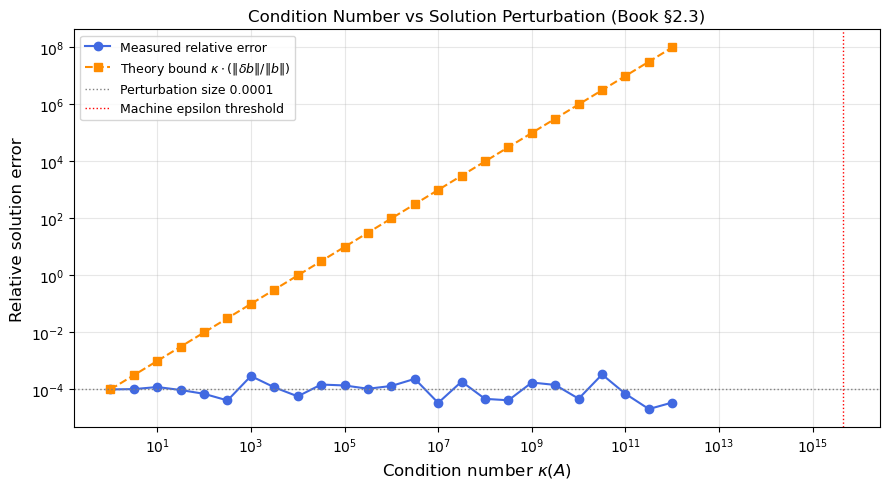

Machine epsilon  : 2.22e-16
At kappa ~ 1e8, relative error ~ 4.67e-05
Beyond kappa ~ 1/eps the solution becomes meaningless (numerical noise dominates).


In [10]:
np.random.seed(42)
n = 20
perturbation_size = 1e-4

def make_matrix_with_condition_number(n, kappa, rng):
    """
    Construct an n×n matrix with condition number kappa.

    Steps:
      1. Draw random orthogonal U, V via QR decomposition.
      2. Build singular values: s[0] = kappa, s[-1] = 1,
         intermediate values spaced geometrically.
      3. Return U @ diag(s) @ V.T
    """
    U, _ = np.linalg.qr(rng.standard_normal((n, n)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    # Geometric spacing: largest singular value = kappa, smallest = 1
    s = np.geomspace(kappa, 1, n)
    return U @ np.diag(s) @ V.T


# --- Experiment ---
condition_numbers = np.logspace(0, 12, 25)   # kappa from 1 to 10^12
rng = np.random.default_rng(42)

rel_errors    = []
theory_bounds = []

b_true = np.ones(n)
delta_b = rng.standard_normal(n)
delta_b = delta_b / np.linalg.norm(delta_b) * perturbation_size * np.linalg.norm(b_true)

for kappa_target in condition_numbers:
    A = make_matrix_with_condition_number(n, kappa_target, rng)

    x = np.linalg.solve(A, b_true)
    x_perturbed = np.linalg.solve(A, b_true + delta_b)

    rel_err = (np.linalg.norm(x_perturbed - x) / np.linalg.norm(x))
    rel_errors.append(rel_err)

    kappa_actual = np.linalg.cond(A)
    bound = kappa_actual * (np.linalg.norm(delta_b) / np.linalg.norm(b_true))
    theory_bounds.append(bound)

rel_errors    = np.array(rel_errors)
theory_bounds = np.array(theory_bounds)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(condition_numbers, rel_errors,    'o-', color='royalblue',  lw=1.5, label='Measured relative error')
ax.loglog(condition_numbers, theory_bounds, 's--', color='darkorange', lw=1.5, label='Theory bound $\\kappa \\cdot (\\|\\delta b\\|/\\|b\\|)$')
ax.axhline(perturbation_size, color='grey', lw=1, ls=':', label=f'Perturbation size {perturbation_size}')
ax.axvline(1/np.finfo(float).eps, color='red', lw=1, ls=':', label='Machine epsilon threshold')
ax.set_xlabel('Condition number $\\kappa(A)$', fontsize=12)
ax.set_ylabel('Relative solution error', fontsize=12)
ax.set_title('Condition Number vs Solution Perturbation (Book §2.3)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Machine epsilon  : {np.finfo(float).eps:.2e}')
print(f'At kappa ~ 1e8, relative error ~ {rel_errors[np.argmin(np.abs(condition_numbers - 1e8))]:.2e}')
print('Beyond kappa ~ 1/eps the solution becomes meaningless (numerical noise dominates).')

## Summary

### Concepts exercised in this lab

| Exercise | Concept |
|----------|---------|
| 1 — 2×2 formula | Determinant, cofactor formula for $A^{-1}$ |
| 2 — Gauss-Jordan | Elementary row operations, RREF |
| 3 — Singular matrices | Determinant = 0, condition number = ∞ |
| 4 — Linear independence | Rank test for independence |
| 5 — Rouché-Capelli | Rank conditions for solvability |
| 6 — Least squares / min-norm | Normal equations, right pseudoinverse |
| 7 — Condition number | Perturbation theory, numerical stability |

### Key take-aways from Sections 2.3–2.4

- The inverse $A^{-1}$ exists if and only if $A$ is **square and full-rank** ($\det A \neq 0$).
- In practice **never form** $A^{-1}$ just to solve $Ax = b$; use `np.linalg.solve` instead.
- A system $Ax = b$ is solvable only when $b$ lies in the **column space** (span) of $A$.
- The **condition number** $\kappa(A)$ quantifies how much numerical errors are amplified; large $\kappa$ signals an ill-conditioned problem.
- When no exact solution exists, the **least-squares** solution minimises the residual; when infinitely many exist, the **minimum-norm** solution is unique.

### Next

**Lab 03** — Eigenvalues, Eigenvectors, and Matrix Decompositions (Book §2.7–2.8)